Alzheimer's Disease Transcriptomics Analysis

Objective: To identify differentially expressed genes (DEG) in the Brain using RNA-seq data from the DataLENS portal (MSBB).

In [ ]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/differential_expression-3.csv")

print(df.head())

  GeneSymbol  EntrezID  logFC                CI  AveExpr    PValue  adjPVal  \
0       APOE       348 -0.009   -0.334 to 0.316   10.071  0.954710  0.99993   
1       APOE       348 -0.040   -0.346 to 0.267   10.073  0.796510  0.99993   
2       APOE       348 -0.308  -0.593 to -0.023   10.071  0.034745  0.44289   
3       APOE       348 -0.160   -0.556 to 0.236   10.073  0.420390  0.99998   
4       APOE       348  0.088   -0.202 to 0.377   10.071  0.545440  0.99979   

  StudyName BrainRegion Contrast StratFactor  
0      MSBB    Amygdala   AD-NCI     CpDxAll  
1      MSBB    Amygdala    C3-C0       CERAD  
2      MSBB    Amygdala    B3-B2       Braak  
3      MSBB    Amygdala    C1-C0       CERAD  
4      MSBB    Amygdala    B2-B1       Braak  


In [6]:
sig_results = df[df["PValue"] < 0.05] 
print(sig_results[["GeneSymbol", "logFC", "PValue", "Contrast"]])

    GeneSymbol  logFC    PValue  Contrast
2         APOE -0.308  0.034745     B3-B2
41         APP -0.177  0.020596    AD-NCI
56         APP -0.233  0.006084    AD-NCI
65         APP -0.441  0.035967    PC-NCI
108       BIN1 -0.364  0.029218    AD-NCI
171       MAPT -0.556  0.032463    AD-NCI
189       MAPT -0.180  0.044163     C3-C0
190       MAPT -0.363  0.046202     C3-C0
201       MAPT -0.773  0.018736    AD-NCI
202       MAPT -0.498  0.036686    AD-NCI
213       MAPT -0.960  0.017608  DNAD-NCI
231       MAPT -0.589  0.026926    AD-NCI
232       MAPT -0.889  0.020567    AD-NCI
243       MAPT -0.960  0.024060  DNAD-NCI


We are 95% sure that these fold changes are linked to disease and not just chance or noise from the sequencing machine

In [11]:
df["neg_log_p"] = -np.log10(df["PValue"])
sig_log_FC = df[(df["PValue"] < 0.05) & (df["logFC"].abs() > 0.1)]
print(sig_log_FC[["GeneSymbol", "logFC", "PValue"]])

    GeneSymbol  logFC    PValue
2         APOE -0.308  0.034745
41         APP -0.177  0.020596
56         APP -0.233  0.006084
65         APP -0.441  0.035967
108       BIN1 -0.364  0.029218
171       MAPT -0.556  0.032463
189       MAPT -0.180  0.044163
190       MAPT -0.363  0.046202
201       MAPT -0.773  0.018736
202       MAPT -0.498  0.036686
213       MAPT -0.960  0.017608
231       MAPT -0.589  0.026926
232       MAPT -0.889  0.020567
243       MAPT -0.960  0.024060


DATA VISUALIZATION: VOLCANO PLOT OF DIFFERENTIALLY EXPRESSED GENES

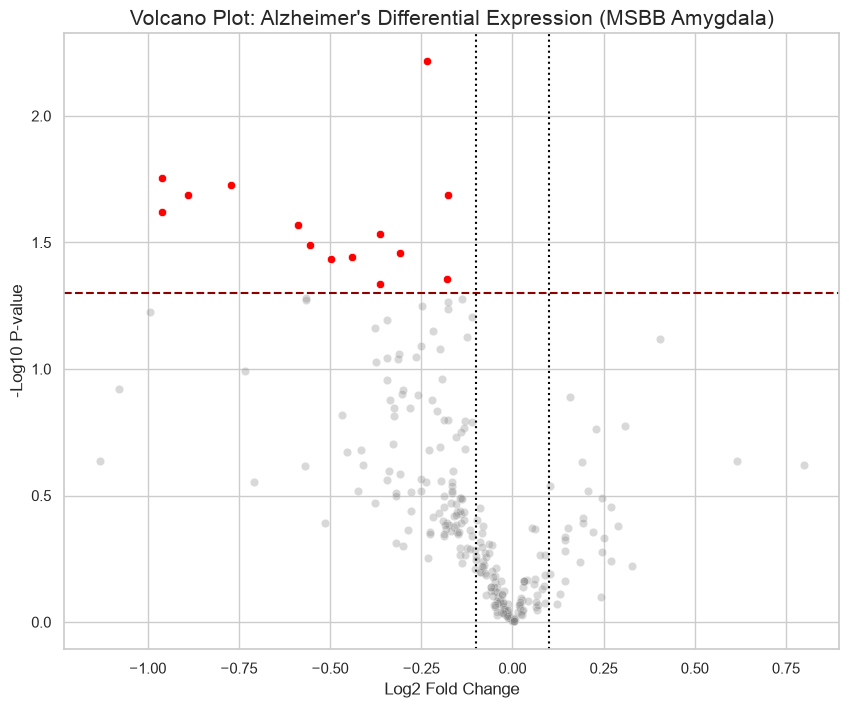

In [12]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,8))

sns.scatterplot(data = df, x="logFC", y="neg_log_p", alpha = 0.3, color="gray")
sns.scatterplot(data= sig_log_FC, x= "logFC", y= "neg_log_p", color= "red")
plt.axhline(-np.log10(0.05), color= "darkred", linestyle= "--",label= "p=0.05")
plt.axvline(0.1, color= "black", linestyle= ":")
plt.axvline(-0.1, color= "black", linestyle= ":")

plt.title("Volcano Plot: Alzheimer's Differential Expression (MSBB Amygdala)", fontsize= 15)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-value", fontsize=12)

plt.show()